# Embedding PCA Eigenvalue Spectrum

Plug-and-play notebook to compare encoders/datasets/PCA dimensions.

It:
- loads one MegaMedical task,
- builds image embeddings with a selected encoder,
- runs PCA,
- computes covariance in PCA space,
- plots eigenvalue magnitudes by component index (largest to smallest).


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sys

# Ensure repo and vendored deps are on path
repo_root = Path("/data/ddmg/mvseg-ordering/")
for path in [repo_root, repo_root / "UniverSeg", repo_root / "MultiverSeg"]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from experiments.regression.training_data_prep import (
    build_embedding_training_data,
    load_megamedical_dataset,
)


In [6]:
# --- Config ---
# Choose either dataset_target OR (task, label, slicing).

DATASET_TARGET = 12            # Example: 0, 1, 2, ...
SPLIT = "train"              # "train" | "val" | "test"
TASK = None                   # Example: "WBC/Blood_cell_counting_and_detection"
LABEL = None                  # Example: 0
SLICING = None                # "midslice" | "maxslice"
DATASET_SIZE = None           # Set an int (e.g. 200) for quicker runs
DATASET_SEED = 42

ENCODER_CFG_PATH = Path("/data/ddmg/mvseg-ordering/experiments/encoder_configs/clip_default.yaml")
DEVICE = "cpu"               # "cpu" or "cuda"
BATCH_SIZE = 16

PCA_K = 32                    # Must be <= min(n_samples, embedding_dim)
STANDARDIZE_EMBEDDINGS = True # Recommended before PCA


In [7]:
dataset = load_megamedical_dataset(
    dataset_target=DATASET_TARGET,
    split=SPLIT,
    task=TASK,
    label=LABEL,
    slicing=SLICING,
    seed=DATASET_SEED,
    dataset_size=DATASET_SIZE,
)

embedding_data = build_embedding_training_data(
    dataset=dataset,
    encoder_cfg_path=ENCODER_CFG_PATH,
    device=DEVICE,
    batch_size=BATCH_SIZE,
)

embeddings = embedding_data.embeddings
print(f"n_images={embeddings.shape[0]:,}, embedding_dim={embeddings.shape[1]:,}")
print(f"data_indices shape={embedding_data.data_indices.shape}")


No updates to index
Filtered task_df: 1248
got task df: 1248


/data/ddmg/mvseg-ordering/experiments/dataset/multisegment2d.py:156: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["label_type"].fillna("soft", inplace=True)


target_datasets: 1248
n_images=60, embedding_dim=512
data_indices shape=(60,)


In [8]:
n_samples, n_features = embeddings.shape
max_k = min(n_samples, n_features)
if PCA_K > max_k:
    raise ValueError(f"PCA_K={PCA_K} exceeds min(n_samples, n_features)={max_k}.")

if STANDARDIZE_EMBEDDINGS:
    scaler = StandardScaler()
    embeddings_for_pca = scaler.fit_transform(embeddings)
else:
    embeddings_for_pca = embeddings.copy()

pca = PCA(n_components=PCA_K, random_state=0)
embeddings_pca = pca.fit_transform(embeddings_for_pca)

covariance_matrix = np.cov(embeddings_pca, rowvar=False, bias=True)
if np.ndim(covariance_matrix) == 0:
    covariance_matrix = np.asarray([[float(covariance_matrix)]], dtype=np.float64)

eigenvalues = np.linalg.eigvalsh(np.asarray(covariance_matrix, dtype=np.float64))
eigenvalue_magnitudes_desc = np.sort(np.abs(eigenvalues))[::-1]
component_indices = np.arange(1, len(eigenvalue_magnitudes_desc) + 1)

print(f"PCA output shape: {embeddings_pca.shape}")
print(f"Covariance shape: {covariance_matrix.shape}")
print(f"Top 10 |eigenvalues|: {eigenvalue_magnitudes_desc[:10]}")


PCA output shape: (60, 32)
Covariance shape: (32, 32)
Top 10 |eigenvalues|: [93.30626867 57.68890361 38.61481286 29.52848834 24.78349166 21.64589055
 18.21869128 17.34417992 16.58776187 15.19943462]


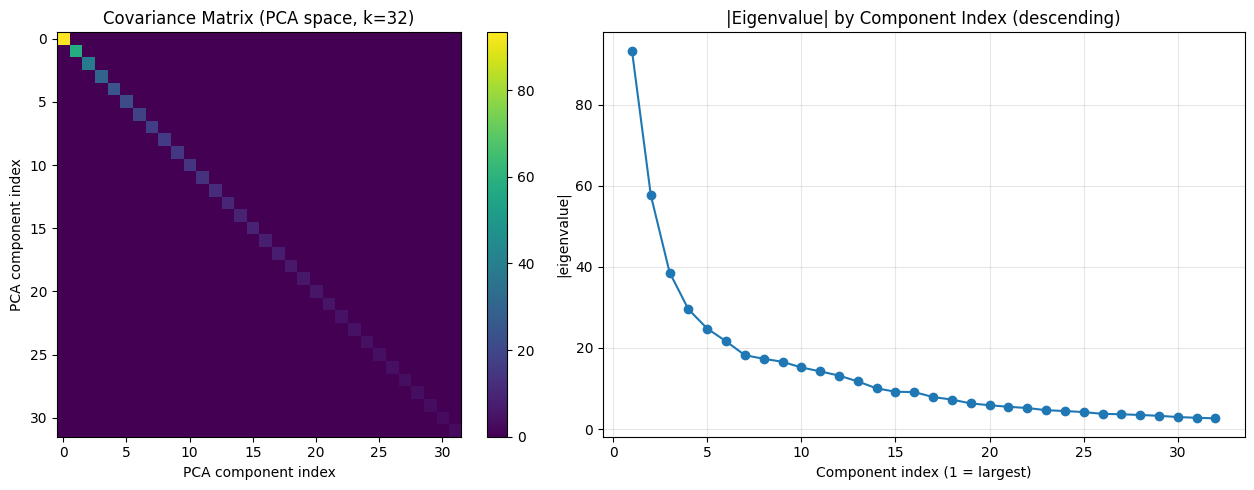

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Covariance heatmap in PCA space.
im = ax[0].imshow(covariance_matrix, cmap="viridis")
ax[0].set_title(f"Covariance Matrix (PCA space, k={PCA_K})")
ax[0].set_xlabel("PCA component index")
ax[0].set_ylabel("PCA component index")
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

# Eigenvalue magnitudes by index (largest to smallest).
ax[1].plot(component_indices, eigenvalue_magnitudes_desc, marker="o", linewidth=1.5)
ax[1].set_title("|Eigenvalue| by Component Index (descending)")
ax[1].set_xlabel("Component index (1 = largest)")
ax[1].set_ylabel("|eigenvalue|")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Optional: log-scale spectrum view (useful when tail values are tiny)
plt.figure(figsize=(7, 4))
plt.semilogy(component_indices, eigenvalue_magnitudes_desc, marker="o", linewidth=1.5)
plt.title("|Eigenvalue| Spectrum (log scale)")
plt.xlabel("Component index (1 = largest)")
plt.ylabel("|eigenvalue| (log)")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()
